## Libraries and Installation

In [32]:
from google.colab import drive
drive.mount('/content/gdrive')
!ls /content/gdrive/MyDrive/deep_text/

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Pranav_LSTM2.ipynb  sherlockholmes.txt
Pranav_LSTM.ipynb   text_generation_sherlock_rnn_temp_exp.ipynb
RNNTorch.ipynb	    TokenLSTM.ipynb


In [33]:
pip install pyspellchecker

In [34]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import platform
import time
import pathlib
import os
from spellchecker import SpellChecker

print('Python version:', platform.python_version())
print('Tensorflow version:', tf.__version__)
print('Keras version:', tf.keras.__version__)

from collections import Counter
import tempfile

Python version: 3.11.12
Tensorflow version: 2.18.0
Keras version: 3.8.0


## Data

In [35]:
cache_dir = './tmp'
file_path = '/content/gdrive/MyDrive/deep_text/sherlockholmes.txt'
print(f"file path: {file_path}")

file path: /content/gdrive/MyDrive/deep_text/sherlockholmes.txt


### Load Data

In [36]:
with open(file_path, 'r', encoding='utf-8') as f:
    text = f.read()
print(f"data has been read successfully...")
print(f"Loaded {len(text)} characters.")

data has been read successfully...
Loaded 561801 characters.


### Data Exploration

In [37]:
print(f"first 250 characters...")
print(f"{text[:250]}")

first 250 characters...
The Adventures of Sherlock Holmes

by Arthur Conan Doyle

I. A SCANDAL IN BOHEMIA


I.

To Sherlock Holmes she is always _the_ woman. I have seldom heard him
mention her under any other name. In his eyes she eclipses and
predominates the whole of her


### Data Preprocessing

In [38]:
print(f"data preprocessing...")
char_set = set(text)

print(f"vocab(char_set) size: {len(char_set)}")
print()

# encode characters
chars_sorted = sorted(char_set)
char2int = {ch:i for i,ch in enumerate(chars_sorted)}

# decode characters
char_array = np.array(chars_sorted)

# encode text
print(f"encode text as vectors...")
text_encoded = np.array([char2int[ch] for ch in text], dtype=np.int32)
print(f"encoded text length: {len(text_encoded)}")
print()

# encoded text shape
print(f"encoded text shape: {text_encoded.shape}")
print()

# print out a few mappings
print(f"print out first few mappings...")
for i in text_encoded[:5]:
  print("{} -> {}".format(i, char_array[i]))
print()

# encoding characters
print(f"{text[:15]} ==> Encoded: {text_encoded[:15]}")
print()
print(f"{text_encoded[:15]} ==> Decoded: {''.join(char_array[text_encoded[:15]])}")

data preprocessing...
vocab(char_set) size: 89

encode text as vectors...
encoded text length: 561801

encoded text shape: (561801,)

print out first few mappings...
42 -> T
57 -> h
54 -> e
1 ->  
23 -> A

The Adventures  ==> Encoded: [42 57 54  1 23 53 71 54 63 69 70 67 54 68  1]

[42 57 54  1 23 53 71 54 63 69 70 67 54 68  1] ==> Decoded: The Adventures 


### Training Sequences

In [39]:
print(f"define sentence length for a single input in characters")
sequence_length = 100
examples_per_epoch = len(text) // (sequence_length + 1)
print(f'examples_per_epoch: {examples_per_epoch}')

define sentence length for a single input in characters
examples_per_epoch: 5562


In [40]:
print(f"create training dataset...")
char_dataset = tf.data.Dataset.from_tensor_slices(text_encoded)
for char in char_dataset.take(5):
    print(char_array[char.numpy()])

create training dataset...
T
h
e
 
A


In [41]:
sequences = char_dataset.batch(sequence_length + 1, drop_remainder=True)
print('Sequences count: {}'.format(examples_per_epoch))
print()
for item in sequences.take(5):
  print(repr(''.join(char_array[item.numpy()])))

Sequences count: 5562

'The Adventures of Sherlock Holmes\n\nby Arthur Conan Doyle\n\nI. A SCANDAL IN BOHEMIA\n\n\nI.\n\nTo Sherlock H'
'olmes she is always _the_ woman. I have seldom heard him\nmention her under any other name. In his eye'
's she eclipses and\npredominates the whole of her sex. It was not that he felt any emotion\nakin to lov'
'e for Irene Adler. All emotions, and that one particularly,\nwere abhorrent to his cold, precise but a'
'dmirably balanced mind. He\nwas, I take it, the most perfect reasoning and observing machine that\nthe '


### Create Data Splits

In [42]:
# basic split
total_chars = len(text_encoded)
train_end = int(total_chars * 0.8)
val_end = int(total_chars * 0.9)

# split text - 80, 10, 10
train_text = text_encoded[:train_end]
val_text = text_encoded[train_end:val_end]
test_text = text_encoded[val_end:]

def split_input_target(chunk):
  input_text = chunk[:-1]
  target_text = chunk[1:]
  return input_text, target_text

def create_dataset(ds, seq_length, batch_size, buffer_size):
  sequences = ds.batch(seq_length + 1, drop_remainder=True)
  dataset = sequences.map(split_input_target)
  dataset = dataset.shuffle(buffer_size).batch(batch_size, drop_remainder=True)

  return dataset

In [43]:
# diverse split
def create_random_data(text_encoded, seq_length, num_examples, batch_size):
  last_start_indx = len(text_encoded) - seq_length - 1

  inputs = np.zeros((num_examples, seq_length), dtype=np.int32)
  targets = np.zeros((num_examples, seq_length), dtype=np.int32)

  # random start
  start_indices = np.random.randint(0, last_start_indx, size=num_examples)

  for i, start_indx in enumerate(start_indices):
    inputs[i] = text_encoded[start_indx:start_indx+seq_length]
    targets[i] = text_encoded[start_indx + 1:start_indx + seq_length + 1]

  dataset = tf.data.Dataset.from_tensor_slices((inputs, targets))
  dataset = dataset.shuffle(10000).batch(batch_size, drop_remainder=True)

  return dataset

In [44]:
# basic split
BUFFER_SIZE = 10000
BATCH_SIZE = 64

# tensorflow datasets
train_dataset = tf.data.Dataset.from_tensor_slices(train_text)
val_dataset = tf.data.Dataset.from_tensor_slices(val_text)
test_dataset = tf.data.Dataset.from_tensor_slices(test_text)

train_dataset = create_dataset(train_dataset, sequence_length, BATCH_SIZE, BUFFER_SIZE)
val_dataset = create_dataset(val_dataset, sequence_length, BATCH_SIZE, BUFFER_SIZE)
test_dataset = create_dataset(test_dataset, sequence_length, BATCH_SIZE, BUFFER_SIZE)

print(f"train batch: {len(train_dataset)}")
print(f"valid batch: {len(val_dataset)}")
print(f"test batch: {len(test_dataset)}")

train batch: 69
valid batch: 8
test batch: 8


In [45]:
# diverse split

# num_train_examples = 10000
# num_val_examples = 1000
# num_test_examples = 1000

# train_dataset = create_random_data(train_text, sequence_length, num_train_examples, BATCH_SIZE)
# val_dataset = create_random_data(val_text, sequence_length, num_val_examples, BATCH_SIZE)
# test_dataset = create_random_data(test_text, sequence_length, num_test_examples, BATCH_SIZE)

## Train Models

### One-Layer LSTM

In [46]:
def build_One_Layer_LSTM(vocab_size, embedding_dim, rnn_units, batch_size):
  model = tf.keras.models.Sequential()

  # input layer
  model.add(tf.keras.layers.InputLayer(batch_input_shape=[batch_size, None]))

  # embedding layer
  model.add(tf.keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim
        ))

  # first lstm layer
  model.add(tf.keras.layers.LSTM(
            units=rnn_units,
            return_sequences=True,
            stateful=True,
            recurrent_initializer=tf.keras.initializers.GlorotNormal()
        ))

  # output layer
  model.add(tf.keras.layers.Dense(vocab_size))

  return model

### Two-Layer LSTM

In [47]:
def build_Two_Layer_LSTM(vocab_size, embedding_dim, rnn_units, batch_size):
  model = tf.keras.models.Sequential()

  # input layer
  model.add(tf.keras.layers.InputLayer(batch_input_shape=[batch_size, None]))

  # embedding layer
  model.add(tf.keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim
        ))

  # first lstm layer
  model.add(  tf.keras.layers.LSTM(
            units=rnn_units,
            return_sequences=True,
            stateful=True,
            recurrent_initializer=tf.keras.initializers.GlorotNormal()
        ))

  # second lstm layer
  model.add(tf.keras.layers.LSTM(
            units=rnn_units,
            return_sequences=True,
            stateful=True,
            recurrent_initializer=tf.keras.initializers.GlorotNormal()
        ))

  # output layer
  model.add(tf.keras.layers.Dense(vocab_size))

  return model

### Build models

In [48]:
vocab_size = len(char_set)
embedding_dim = 256
rnn_units = 1024
BATCH_SIZE = 64

In [49]:
one_layer_lstm = build_One_Layer_LSTM(vocab_size, embedding_dim, rnn_units, BATCH_SIZE)
two_layer_lstm = build_Two_Layer_LSTM(vocab_size, embedding_dim, rnn_units, BATCH_SIZE)

In [50]:
one_layer_lstm.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (64, None, 256)        │        22,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (64, None, 1024)       │     5,246,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (64, None, 89)         │        91,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,360,985 (20.45 MB)

 Trainable params: 5,360,985 (20.45 MB)

 Non-trainable params: 0 (0.00 B)

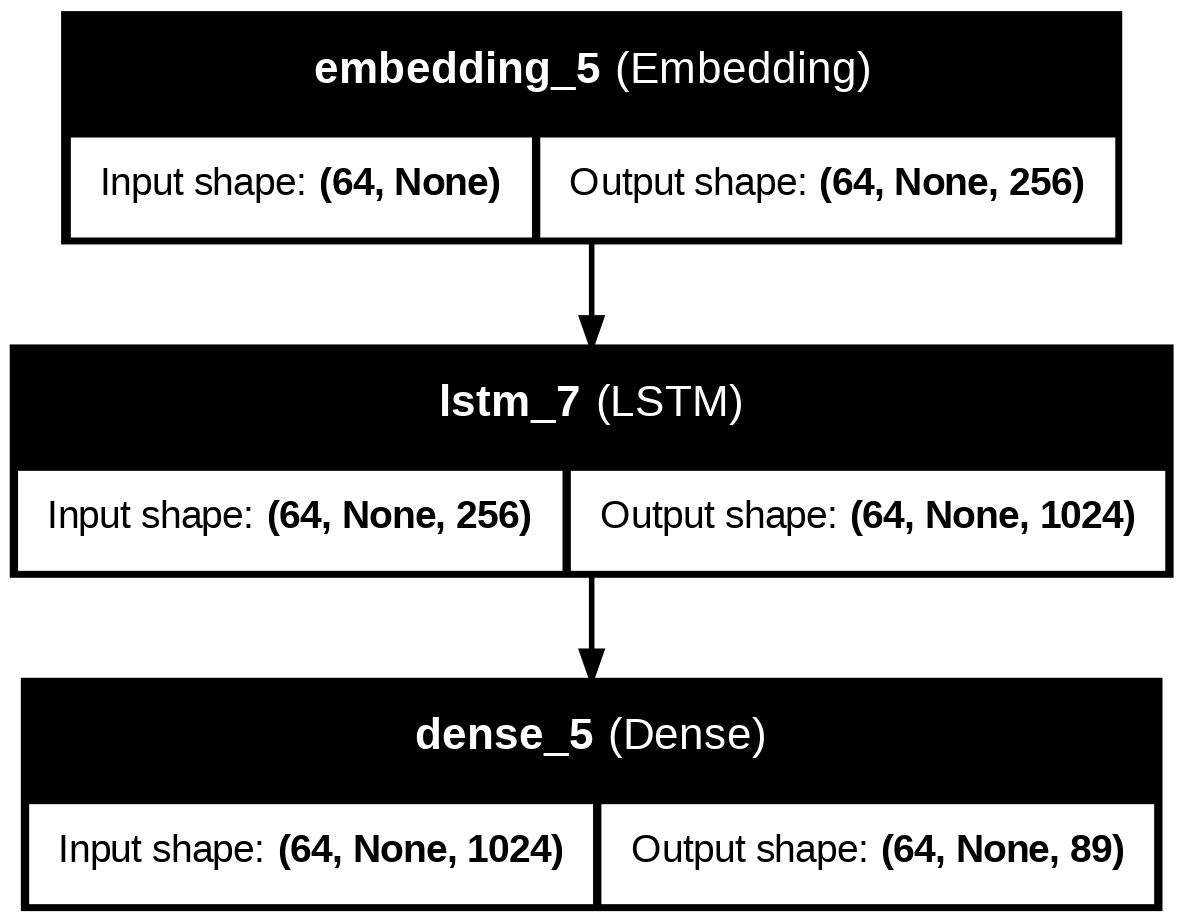

In [51]:
tf.keras.utils.plot_model(
    one_layer_lstm,
    show_shapes=True,
    show_layer_names=True,
)

In [52]:
two_layer_lstm.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (64, None, 256)        │        22,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (64, None, 1024)       │     5,246,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (64, None, 1024)       │     8,392,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (64, None, 89)         │        91,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,753,689 (52.47 MB)

 Trainable params: 13,753,689 (52.47 MB)

 Non-trainable params: 0 (0.00 B)

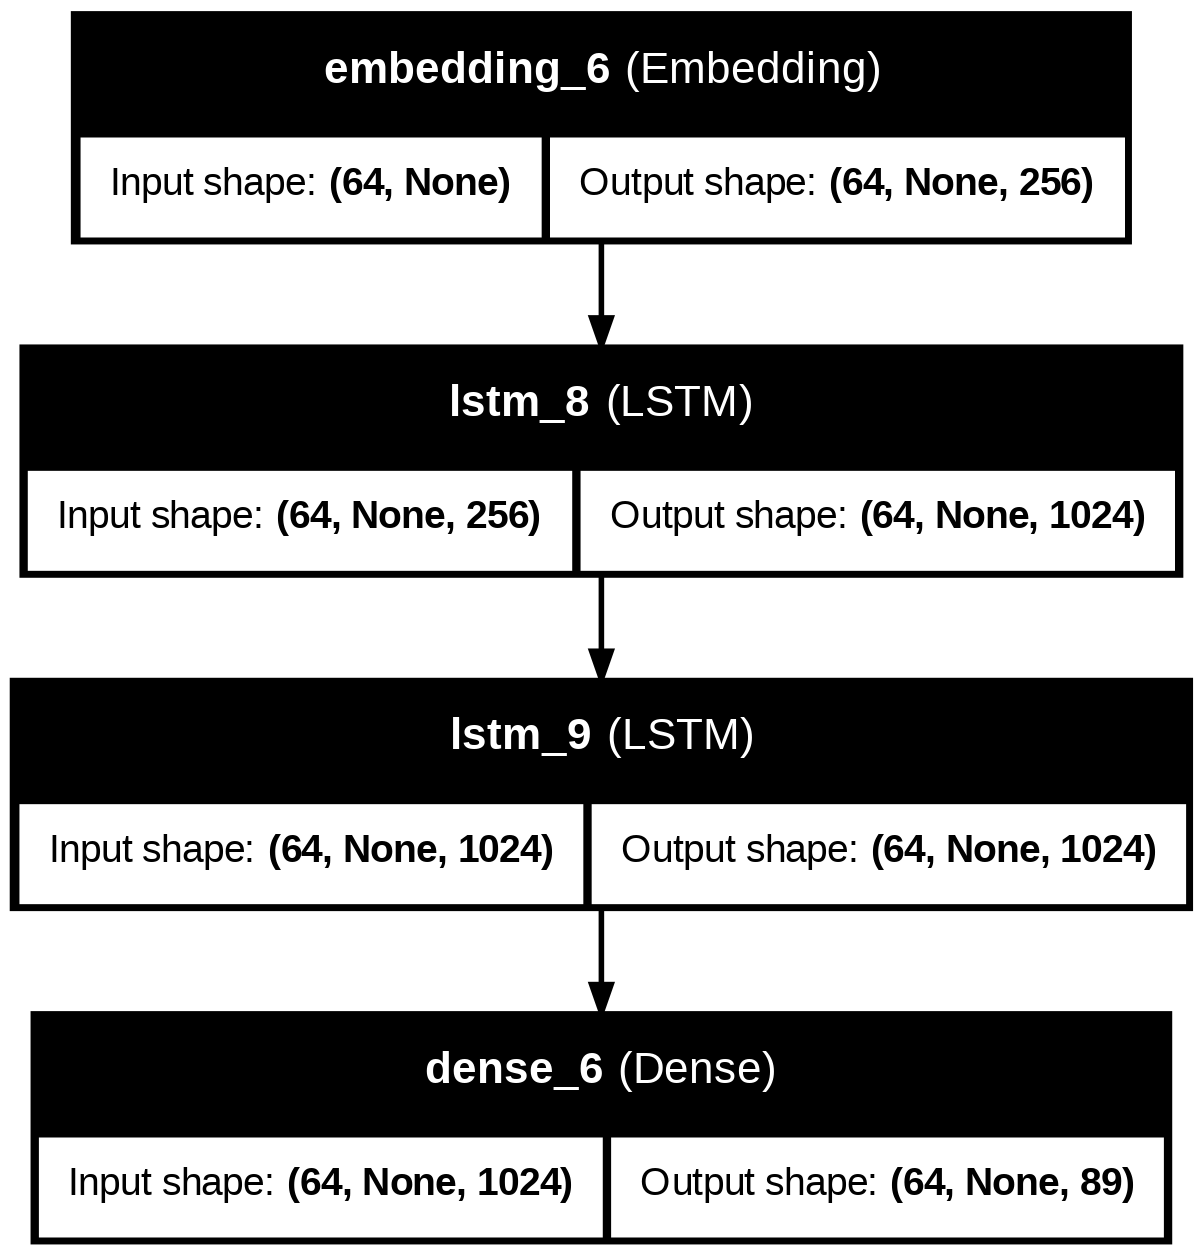

In [53]:
tf.keras.utils.plot_model(
    two_layer_lstm,
    show_shapes=True,
    show_layer_names=True,
)

### Loss Function

In [54]:
def loss(labels, logits):
    """
    Define the loss function for training.
    """
    return tf.keras.losses.sparse_categorical_crossentropy(
        y_true=labels,
        y_pred=logits,
        from_logits=True
    )

### Training Loop

In [59]:
def train_model(model_build, model_name, vocab_size, embedding_dim, rnn_units,
                batch_size, train_dataset, val_dataset, epochs=40, lr=0.001):

  # build model
  model = model_build(vocab_size, embedding_dim, rnn_units, batch_size)

  # compile model
  optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
  model.compile(
        optimizer=optimizer,
        loss=loss
    )

  model.summary()


  temp_dir = tempfile.mkdtemp()
  checkpoint_dir = os.path.join(temp_dir, f'model_checkpoint/{model_name}')
  os.makedirs(checkpoint_dir, exist_ok=True)
  print(f"Model checkpoints will be saved to the temporary checkpoint directory: {checkpoint_dir}")
  checkpoint_prefix = os.path.join(checkpoint_dir, 'ckpt_{epoch}.weights.h5')

  checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
      filepath=checkpoint_prefix,
      save_weights_only=True
    )

  print(f"\nTraining {model_name} model...\n")
  history = model.fit(
      x=train_dataset,
      epochs=epochs,
      validation_data=val_dataset,
      callbacks=[checkpoint_callback]
    )

  return model, history, checkpoint_prefix

In [60]:
vocab_size = len(char_set)
embedding_dim = 256
rnn_units = 1024
batch_size = 64
epochs = 40
learning_rate = 0.001

In [ ]:
one_layer_model, one_layer_history, one_layer_checkpoint = train_model(
    build_One_Layer_LSTM,
    'One-Layer-LSTM',
    vocab_size,
    embedding_dim,
    rnn_units,
    batch_size,
    train_dataset,
    val_dataset,
    epochs=epochs,
    lr = learning_rate
)

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ (64, None, 256)        │        22,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (64, None, 1024)       │     5,246,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (64, None, 89)         │        91,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,360,985 (20.45 MB)

 Trainable params: 5,360,985 (20.45 MB)

 Non-trainable params: 0 (0.00 B)

Model checkpoints will be saved to the temporary checkpoint directory: /tmp/tmp75_tc5np/model_checkpoint/One-Layer-LSTM

Training One-Layer-LSTM model...

Epoch 1/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 3.2185 - val_loss: 2.3515
Epoch 2/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 2.3000 - val_loss: 2.0572
Epoch 3/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 2.0305 - val_loss: 1.8527
Epoch 4/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 1.8425 - val_loss: 1.7136
Epoch 5/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 1.7088 - val_loss: 1.6195
Epoch 6/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 1.6032 - val_loss: 1.5407
Epoch 7/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 1.5257 - val_loss: 1.4976
Epoch 8/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 1.4548 - val_loss: 1.4587
Epoch 9/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 1.4007 - val_loss: 1.4236
Epoch 10/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 1.3514 - val_loss: 1

In [ ]:
two_layer_model, two_layer_history, two_layer_checkpoint = train_model(
    build_Two_Layer_LSTM,
    'Two-Layer-LSTM',
    vocab_size,
    embedding_dim,
    rnn_units,
    batch_size,
    train_dataset,
    val_dataset,
    epochs=epochs,
    lr = learning_rate
)

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(one_layer_history.history['loss'], label='One Layer LSTM(Train)')
plt.plot(one_layer_history.history['val_loss'], label='One Layer LSTM(Val)')
plt.plot(two_layer_history.history['loss'], label='Two Layer LSTM(Train)')
plt.plot(two_layer_history.history['val_loss'], label='Two Layer LSTM(Val)')
plt.title('Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(linestyle='--', linewidth=1, alpha=0.5)
plt.show()

## Evaluation

In [ ]:
def generate_text(model, start_text, generate_tokens=1000, temperature=1.0):
  if isinstance(model, tf.keras.Sequential):
    if len(model.layers) == 4:
      inference_model = build_One_Layer_LSTM(vocab_size, embedding_dim, rnn_units, batch_size=1)
      checkpoint = one_layer_checkpoint
    else:
      inference_model = build_Two_Layer_LSTM(vocab_size, embedding_dim, rnn_units, batch_size=1)
      checkpoint = two_layer_checkpoint


    latest_checkpoint = tf.train_latest_checkpoint(os.path.dirname(checkpoint))
    inference_model.load_weights(latest_checkpoint)

    inference_model.build(tf.TensorShape([1, None]))

    input_indices = [char2int[s] for s in start_text]
    input_indices = tf.expand_dims(input_indices, 0)

    # store generated results
    text_generated = []

    inference_model.reset_states()

    for char_indx in range(generate_tokens):
      predictions = inference_model(input_indices)
      predictions = tf.squeeze(predictions, 0)

      predictions = predictions / temperature
      predicted_id = tf.random.categorical(
          tf.expand_dims(predictions[-1], 0),
          num_samples=1
      )[0, 0].numpy()

      input_indices = tf.expand_dims([predicted_id], 0)

      text_generated.append(char_array[predicted_id])

    return start_text + "".join(text_generated)

In [ ]:
def nucleus_sampling(logits, p=0.9):
  sorted_indices = tf.argsort(logits, direction="DESCENDING")
  sorted_logits = tf.gather(logits, sorted_indices)

  # compute softmax
  sorted_probs = tf.nn.softmax(sorted_logits)

  # compute cumulative probability
  cumulative_prob = tf.cumsum(sorted_probs)

  # find indices where cumulative probability < p
  nucleus_indices = tf.where(cumulative_prob < p)

  if tf.shape(nucleus_indices)[0] < tf.shape(sorted_indices)[0]:
    nucleus_indices = tf.concat([
        nucleus_indices,
        tf.reshape(tf.cast(tf.shape(nucleus_indices)[0], tf.int32), [1, 1])
    ], axis=0)

  nucleus_indices = tf.reshape(nucleus_indices, [-1])
  nucleus_token_indices = tf.gather(sorted_indices, nucleus_indices)

  nucleus_logits = tf.gather(logits, nucleus_token_indices)

  predicted_id = tf.random.categorical(
        tf.reshape(nucleus_logits, [1, -1]),
        num_samples=1
    )[0, 0]

  return tf.gather(nucleus_token_indices, predicted_id)

In [ ]:
def generate_text_nucleus(model, start_text, generate_tokens, temperature=1.0, p=0.9):
  if isinstance(model, tf.keras.Sequential):
    if len(model.layers) == 4:
      inference_model = build_One_Layer_LSTM(vocab_size, embedding_dim, rnn_units, batch_size=1)
      checkpoint = one_layer_checkpoint
    else:
      inference_model = build_Two_Layer_LSTM(vocab_size, embedding_dim, rnn_units, batch_size=1)
      checkpoint = two_layer_checkpoint

    latest_checkpoint = tf.train.latest_checkpoint(os.path.dirname(checkpoint))
    inference_model.load_weights(latest_checkpoint)
    inference_model.build(tf.TensorShape([1, None]))

    input_indices = [char2int[s] for s in start_text]
    input_indices = tf.expand_dims(input_indices, 0)

    text_generated = []

    inference_model.reset_states()

    for char_indx in range(generate_tokens):
      predictions = inference_model(input_indices)
      preidctions = tf.squeeze(predictions, 0)

      # temperature
      predictions = predictions / temperature
      last_prediction = predictions[-1]

      # nucleus sampling
      sorted_indices = tf.argsort(last_prediction, direction='DESCENDING')
      sorted_prob = tf.nn.softmax(tf.gather(last_prediction, sorted_indices))

      cumulative_prob = tf.cumsum(sorted_prob)

      mask = cumulative_prob < p

      mask = tf.concat([mask, tf.ones(1, dtype=tf.bool)], 0)

      nucleus_indices = tf.boolean_mask(sorted_indices, mask)
      nucleus_prob = tf.boolean_mask(sorted_prob, mask)

      nucleus_prob = nucleus_prob / tf.reduce_sum(nucleus_prob)

      sample_id = tf.random.categorical(
            tf.math.log(tf.reshape(nucleus_prob, [1, -1])),
            num_samples=1
        )[0, 0].numpy()

      predicted_id = nucleus_indices[sample_id].numpy()

      input_indices = tf.expand_dims([predicted_id], 0)

      text_generated.append(char_array[predicted_id])

    return start_text+ ''.join(text_generated)

In [ ]:
def test_generation():
  text = "Sherlock Holmes looked at me with a smile. "

  temperatures = [0.1, 0.4, 0.7, 1.0]
  print(f"one layer lstm text generation.......")
  for temp in temperatures:
    print(f"temperature: {temp}.......")
    print(f"regular sampling:")
    generated_text = generate_text('One-Layer-LSTM', text, generate_tokens=200, temperature=temp)
    print(f"{generated_text}")

    print(f"nucleus sampling....")
    generated_text_nucleus = generate_text_nucleus('One-Layer-LSTM', text, generate_tokens=200, temperature=temp, p=0.9)
    print(f"{generated_text_nucleus}")


  print(f"two layer lstm text generation.......")
  for temp in temperatures:
    print(f"temperature: {temp}.......")
    print(f"regular sampling:")
    generated_text = generate_text('Two-Layer-LSTM', text, generate_tokens=200, temperature=temp)
    print(f"{generated_text}")

    print(f"nucleus sampling....")
    generated_text_nucleus = generate_text_nucleus('Two-Layer-LSTM', text, generate_tokens=200, temperature=temp, p=0.9)
    print(f"{generated_text_nucleus}")


In [ ]:
def test_set_evaluation():
  print(f"one layer LSTM test evaluation...")
  one_layer_test_loss = one_layer_lstm.evaluate(test_dataset, verbose=1)
  print(f"One-Layer LSTM Test-Loss: {one_layer_test_loss:.4f}")

  print(f"Two layer LSTM test evaluation...")
  two_layer_test_loss = two_layer_lstm.evaluate(test_dataset, verbose=1)
  print(f"Two-Layer LSTM Test-Loss: {two_layer_test_loss:.4f}")

  # plot results
  plt.figure(figsize=(8, 5))
  plt.bar(['One-Layer LSTM', 'Two-Layer LSTM'], [one_layer_test_loss, two_layer_test_loss])
  plt.title('Test Loss Comparison')
  plt.ylabel('Loss')
  plt.grid(axis='y', linestyle='--', alpha=0.7)
  plt.show()


In [ ]:
test_generation()

In [ ]:
test_set_evaluation()